# HW3 — Airbnb price prediction

В этой тетрадке выполнены все требуемые этапы задания:

1. Анализ данных  
2. Проектирование признаков  
3. Обучение ансамблевой модели  
4. Подбор гиперпараметров + кросс-валидация  
5. Расчёт `RMSE` на тесте и `95%` доверительного интервала  
6. Краткие комментарии по каждому этапу

> Датасет: `Airbnb_Data.csv`  
> Целевая переменная: `log_price`


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

np.random.seed(42)
pd.set_option('display.max_columns', 200)

## 1. Загрузка данных

In [2]:
df = pd.read_csv('Airbnb_Data.csv')
print(df.shape)
df.head()

(74111, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


## 2. Разделение на train / test
Разбиение делаем точно как в шаблоне задания.

In [3]:
X = df.drop('log_price', axis=1)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (59288, 28)
X_test : (14823, 28)


## 3. Первичный анализ данных

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [5]:
missing = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename('missing_share')
      .to_frame()
)
missing.head(15)

,missing_share
host_response_rate,0.246913
review_scores_rating,0.225635
first_review,0.214057
last_review,0.213558
thumbnail_url,0.110861
neighbourhood,0.092726
zipcode,0.013035
bathrooms,0.002699
host_identity_verified,0.002537
host_has_profile_pic,0.002537


In [6]:
df.describe(include='all').T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,74111.0,NaN,NaN,NaN,11266617.102468,6081734.886894,344.0,6261964.5,12254147.0,16402260.5,21230903.0
log_price,74111.0,NaN,NaN,NaN,4.782069,0.717394,0.0,4.317488,4.70953,5.220356,7.600402
property_type,74111,35,Apartment,49003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,74111,3,Entire home/apt,41310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amenities,74111,67122,{},586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,74111.0,NaN,NaN,NaN,3.155146,2.153589,1.0,2.0,2.0,4.0,16.0
bathrooms,73911.0,NaN,NaN,NaN,1.235263,0.582044,0.0,1.0,1.0,1.0,8.0
bed_type,74111,5,Real Bed,72028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cancellation_policy,74111,5,strict,32374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cleaning_fee,74111,2,True,54403,NaN,NaN,NaN,NaN,NaN,NaN,NaN


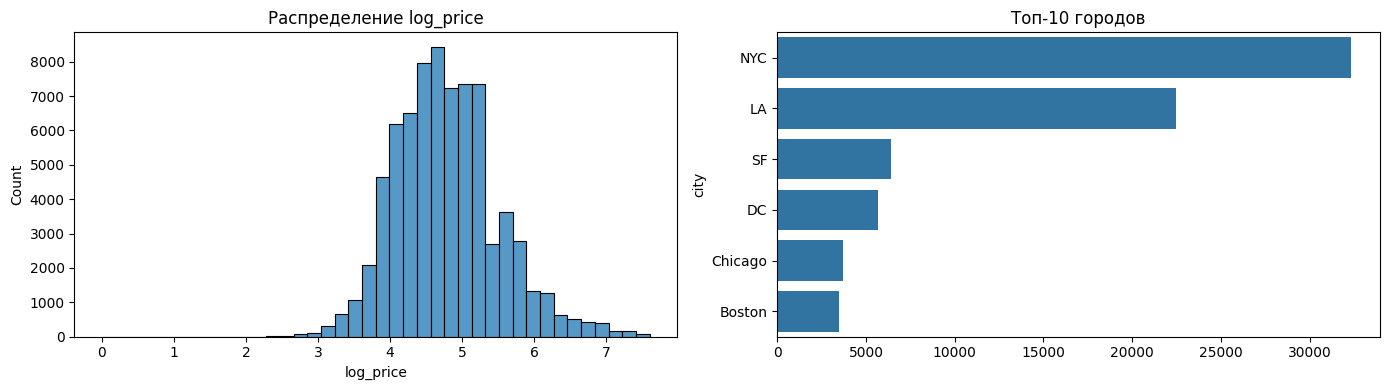

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['log_price'], bins=40, ax=axes[0])
axes[0].set_title('Распределение log_price')

top_cities = df['city'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[1])
axes[1].set_title('Топ-10 городов')

plt.tight_layout()

### Комментарий к EDA

По данным видно несколько важных моментов:

- в датасете есть и числовые, и категориальные, и текстовые признаки;
- есть заметное количество пропусков в `review_scores_rating`, `host_response_rate`, `first_review`, `last_review`, `thumbnail_url`, `neighbourhood`;
- часть признаков представлены в неудобном формате и требуют преобразования:
  - проценты (`host_response_rate`);
  - даты (`host_since`, `first_review`, `last_review`);
  - длинные текстовые поля (`name`, `description`, `amenities`).

Из этого следует, что качество модели сильно зависит не только от выбора алгоритма, но и от аккуратной генерации новых признаков.


## 4. Feature engineering

In [8]:
class AirbnbFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for col in ['first_review', 'last_review', 'host_since']:
            X[col] = pd.to_datetime(X[col], errors='coerce')

        ref_date = pd.Timestamp('2017-01-01')

        X['host_tenure_days'] = (ref_date - X['host_since']).dt.days
        X['days_since_first_review'] = (ref_date - X['first_review']).dt.days
        X['days_since_last_review'] = (ref_date - X['last_review']).dt.days

        X['host_since_year'] = X['host_since'].dt.year
        X['first_review_year'] = X['first_review'].dt.year
        X['last_review_year'] = X['last_review'].dt.year

        X['host_response_rate_num'] = (
            X['host_response_rate']
            .astype(str)
            .str.rstrip('%')
            .replace('nan', np.nan)
        )
        X['host_response_rate_num'] = pd.to_numeric(
            X['host_response_rate_num'], errors='coerce'
        )

        for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
            X[col] = X[col].map({'t': 1, 'f': 0, True: 1, False: 0})

        X['amenities_count'] = (
            X['amenities'].fillna('').str.count(',') +
            X['amenities'].fillna('').ne('').astype(int)
        )
        X['amenities_char_len'] = X['amenities'].fillna('').str.len()

        X['description_len'] = X['description'].fillna('').str.len()
        X['description_word_count'] = X['description'].fillna('').str.split().str.len()

        X['name_len'] = X['name'].fillna('').str.len()
        X['name_word_count'] = X['name'].fillna('').str.split().str.len()

        X['has_thumbnail'] = X['thumbnail_url'].notna().astype(int)

        X['beds_per_bedroom'] = X['beds'] / X['bedrooms'].replace(0, np.nan)
        X['bathrooms_per_guest'] = X['bathrooms'] / X['accommodates'].replace(0, np.nan)

        review_age_years = (X['days_since_first_review'] / 365.25).clip(lower=0.25)
        X['reviews_per_year_proxy'] = X['number_of_reviews'] / review_age_years

        X = X.replace([np.inf, -np.inf], np.nan)

        drop_cols = [
            'id', 'host_since', 'first_review', 'last_review',
            'host_response_rate', 'amenities', 'description',
            'name', 'thumbnail_url'
        ]
        X = X.drop(columns=[c for c in drop_cols if c in X.columns])

        return X

In [9]:
X_train_fe = AirbnbFeatureEngineer().fit_transform(X_train)

cat_cols = X_train_fe.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X_train_fe.columns if c not in cat_cols]

print('Количество признаков после FE:', X_train_fe.shape[1])
print('Категориальные признаки:', cat_cols)
print('Числовые признаки:', len(num_cols))

Количество признаков после FE: 36
Категориальные признаки: ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'neighbourhood', 'zipcode']
Числовые признаки: 29


### Комментарий по признакам

Я добавил признаки нескольких типов:

- **временные**: стаж хоста, давность отзывов, годы начала активности;
- **числовые из строк**: `host_response_rate_num`;
- **текстовые прокси**: длина описания, количество слов, число amenities;
- **логические**: наличие фото, подтверждение личности, instant booking;
- **отношения признаков**: кроватей на спальню, ванных на гостя, приблизительная интенсивность отзывов.

Такой подход обычно даёт заметно лучший результат, чем использование исходных признаков “как есть”.


## 5. Препроцессинг

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
                ]
            ),
            cat_cols,
        ),
        (
            'num',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                ]
            ),
            num_cols,
        ),
    ]
)

## 6. Ансамблевая модель
Используем ансамбль из `RandomForestRegressor` и `ExtraTreesRegressor` через `VotingRegressor`.

In [11]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
et = ExtraTreesRegressor(random_state=42, n_jobs=-1)

ensemble = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('et', et),
    ],
    n_jobs=-1
)

pipe = Pipeline(
    steps=[
        ('features', AirbnbFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('model', ensemble),
    ]
)

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

## 7. Подбор гиперпараметров и кросс-валидация

In [12]:
param_distributions = {
    'model__weights': [(1, 1), (2, 1), (1, 2), (3, 2), (2, 3)],
    'model__rf__n_estimators': randint(120, 260),
    'model__rf__max_depth': [None, 12, 16, 20, 24],
    'model__rf__min_samples_split': randint(2, 10),
    'model__rf__min_samples_leaf': randint(1, 5),
    'model__rf__max_features': ['sqrt', 'log2', 0.5, 0.7],

    'model__et__n_estimators': randint(120, 260),
    'model__et__max_depth': [None, 12, 16, 20, 24],
    'model__et__min_samples_split': randint(2, 10),
    'model__et__min_samples_leaf': randint(1, 5),
    'model__et__max_features': ['sqrt', 'log2', 0.5, 0.7],
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=8,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print('Best CV RMSE:', -search.best_score_)
print('Best params:')
search.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV RMSE: 0.39628460716119945
Best params:


{'model__et__max_depth': 20,
 'model__et__max_features': 'sqrt',
 'model__et__min_samples_leaf': 1,
 'model__et__min_samples_split': 5,
 'model__et__n_estimators': 177,
 'model__rf__max_depth': 24,
 'model__rf__max_features': 0.7,
 'model__rf__min_samples_leaf': 1,
 'model__rf__min_samples_split': 2,
 'model__rf__n_estimators': 178,
 'model__weights': (2, 1)}

### Комментарий

Подбор параметров делаем по кросс-валидации, чтобы не подгонять модель под одну случайную разбивку.  
Метрика на кросс-валидации — `RMSE`, потому что именно её требует задание.


## 8. Финальная оценка на тестовой выборке

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

best_model = search.best_estimator_

test_pred = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print('Test RMSE:', test_rmse)

Test RMSE: 0.38992593683038607


## 9. 95% доверительный интервал для RMSE

In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)

y_test_np = np.asarray(y_test)
pred_np = np.asarray(test_pred)

boot_rmse = []
n = len(y_test_np)

for _ in range(1000):
    idx = rng.integers(0, n, size=n)
    rmse_i = np.sqrt(mean_squared_error(y_test_np[idx], pred_np[idx]))
    boot_rmse.append(rmse_i)

ci_low, ci_high = np.percentile(boot_rmse, [2.5, 97.5])

print(f'RMSE = {test_rmse:.4f}')
print(f'95% CI: [{ci_low:.4f}; {ci_high:.4f}]')

RMSE = 0.3899
95% CI: [0.3814; 0.3982]


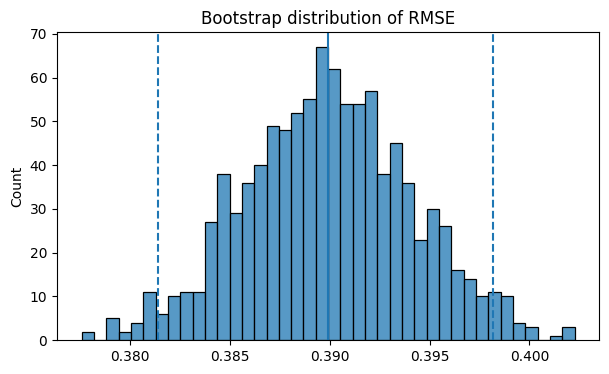

In [17]:
plt.figure(figsize=(7, 4))
sns.histplot(boot_rmse, bins=40)
plt.axvline(ci_low, linestyle='--')
plt.axvline(ci_high, linestyle='--')
plt.axvline(test_rmse)
plt.title('Bootstrap distribution of RMSE')
plt.show()

## 10. Итоговый комментарий

### Что было сделано
1. Проведён первичный анализ данных: изучены типы признаков, пропуски, распределения.
2. Выполнено проектирование признаков:
   - преобразованы даты;
   - извлечены числовые признаки из процентов и текста;
   - добавлены простые отношения между признаками.
3. Обучена **ансамблевая модель** (`VotingRegressor` из `RandomForest` и `ExtraTrees`).
4. Выполнен подбор гиперпараметров через `RandomizedSearchCV`.
5. Использована кросс-валидация для более надёжной оценки качества.
6. Посчитан `RMSE` на тестовой выборке и построен `95%` доверительный интервал через bootstrap.

### Почему выбран именно такой подход
- Датасет смешанный: здесь есть категории, тексты, даты и пропуски.
- Деревянные ансамбли хорошо работают на табличных данных и устойчивы к нелинейностям.
- `VotingRegressor` позволяет объединить преимущества двух разных ансамблей.
- Bootstrap-интервал даёт понятную оценку устойчивости тестового RMSE.

### Возможные улучшения
- попробовать `CatBoostRegressor`;
- выделить более сильные текстовые признаки из `description` и `amenities`;
- аккуратнее обработать редкие категории и zipcode;
- добавить географические кластеры по широте/долготе.
